In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
# LOAD BUS DATA

In [4]:
bus_2023 = pd.read_excel(r"C:\Users\milli\OneDrive\Documents\Data Analytics_Main\PRESCRIPTIVE\GROUP ASSIGNMENT\PART 1\part1\bus_delay_2023.xlsx")
bus_2024 = pd.read_excel(r"C:\Users\milli\OneDrive\Documents\Data Analytics_Main\PRESCRIPTIVE\GROUP ASSIGNMENT\PART 1\part1\bus_delay_2024.xlsx")
bus_2025 = pd.read_csv(r"C:\Users\milli\OneDrive\Documents\Data Analytics_Main\PRESCRIPTIVE\GROUP ASSIGNMENT\PART 1\part1\bus_delay_2025_2026.csv")

In [5]:
# Check structure

print("BUS 2023 SHAPE:", bus_2023.shape)
print("BUS 2024 SHAPE:", bus_2024.shape)
print("BUS 2025 SHAPE:", bus_2025.shape)

print("\nBUS 2023 COLUMNS:\n", bus_2023.columns)
print("\nBUS 2024 COLUMNS:\n", bus_2024.columns)
print("\nBUS 2025 COLUMNS:\n", bus_2025.columns)

BUS 2023 SHAPE: (56207, 10)
BUS 2024 SHAPE: (59643, 10)
BUS 2025 SHAPE: (69037, 11)

BUS 2023 COLUMNS:
 Index(['Date', 'Route', 'Time', 'Day', 'Location', 'Incident', 'Min Delay',
       'Min Gap', 'Direction', 'Vehicle'],
      dtype='object')

BUS 2024 COLUMNS:
 Index(['Date', 'Route', 'Time', 'Day', 'Location', 'Incident', 'Min Delay',
       'Min Gap', 'Direction', 'Vehicle'],
      dtype='object')

BUS 2025 COLUMNS:
 Index(['_id', 'Date', 'Line', 'Time', 'Day', 'Station', 'Code', 'Min Delay',
       'Min Gap', 'Bound', 'Vehicle'],
      dtype='object')


In [6]:
# Preview first row
print("\nBUS 2023 HEAD")
print(bus_2023.head())

print("\nBUS 2024 HEAD")
print(bus_2024.head())

print("\nBUS 2025 HEAD")
print(bus_2025.head())


BUS 2023 HEAD
        Date Route   Time     Day               Location  \
0 2023-01-01    91  02:30  Sunday  WOODBINE AND MORTIMER   
1 2023-01-01    69  02:34  Sunday         WARDEN STATION   
2 2023-01-01    35  03:06  Sunday           JANE STATION   
3 2023-01-01   900  03:14  Sunday        KIPLING STATION   
4 2023-01-01    85  03:43  Sunday         MEADOWALE LOOP   

                Incident  Min Delay  Min Gap Direction  Vehicle  
0              Diversion         81      111       NaN     8772  
1               Security         22       44         S     8407  
2  Cleaning - Unsanitary         30       60         N     1051  
3               Security         17       17       NaN     3334  
4               Security          1        1       NaN     1559  

BUS 2024 HEAD
        Date Route   Time     Day              Location       Incident  \
0 2024-01-01    89  02:08  Monday    KEELE AND GLENLAKE         Vision   
1 2024-01-01    39  02:30  Monday         FINCH STATION  General 

In [6]:
bus_2023.info()
bus_2024.info()
bus_2025.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56207 entries, 0 to 56206
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       56207 non-null  datetime64[ns]
 1   Route      55637 non-null  object        
 2   Time       56207 non-null  object        
 3   Day        56207 non-null  object        
 4   Location   56207 non-null  object        
 5   Incident   56207 non-null  object        
 6   Min Delay  56207 non-null  int64         
 7   Min Gap    56207 non-null  int64         
 8   Direction  46667 non-null  object        
 9   Vehicle    56207 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(6)
memory usage: 4.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59643 entries, 0 to 59642
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       59643 non-null  datetime64[ns]
 1   Rou

In [7]:
bus_2023.describe()
bus_2024.describe()
bus_2025.describe()

,_id,Min Delay,Min Gap,Vehicle
count,69037.000000,69037.000000,69037.000000,69037.000000
mean,34519.000000,20.716456,32.876009,5966.248809
std,19929.409604,51.580283,53.709201,3759.502950
min,1.000000,0.000000,0.000000,0.000000
25%,17260.000000,8.000000,16.000000,3329.000000
50%,34519.000000,11.000000,22.000000,7118.000000
75%,51778.000000,20.000000,40.000000,8609.000000
max,69037.000000,999.000000,997.000000,94633.000000


In [14]:
# Standardize column names in the 2025
bus_2025 = bus_2025.rename(columns={
    'Line': 'Route',
    'Bound': 'Direction'
})

# Check results
print("\nCleaned 2023 columns:", bus_2023.columns.tolist())
print("Cleaned 2024 columns:", bus_2024.columns.tolist())
print("Cleaned 2025 columns:", bus_2025.columns.tolist())


Cleaned 2023 columns: ['Date', 'Route', 'Time', 'Day', 'Location', 'Incident', 'Min Delay', 'Min Gap', 'Direction', 'Vehicle']
Cleaned 2024 columns: ['Date', 'Route', 'Time', 'Day', 'Location', 'Incident', 'Min Delay', 'Min Gap', 'Direction', 'Vehicle']
Cleaned 2025 columns: ['_id', 'Date', 'Route', 'Time', 'Day', 'Station', 'Code', 'Min Delay', 'Min Gap', 'Direction', 'Vehicle']


# Preprocessing of bus datasets

In [15]:
# Align text columns
text_cols = ['Date', 'Route', 'Direction', 'Time', 'Day', 'Incident', 'Location']

for col in text_cols:
    if col in bus_2023.columns:
        bus_2023[col] = bus_2023[col].astype(str)
    if col in bus_2024.columns:
        bus_2024[col] = bus_2024[col].astype(str)
    if col in bus_2025.columns:
        bus_2025[col] = bus_2025[col].astype(str)

# Align numeric columns
numeric_cols = ['Min_Delay', 'Min_Gap', 'Vehicle']

for col in numeric_cols:
    if col in bus_2023.columns:
        bus_2023[col] = pd.to_numeric(bus_2023[col], errors='coerce')
    if col in bus_2024.columns:
        bus_2024[col] = pd.to_numeric(bus_2024[col], errors='coerce')
    if col in bus_2025.columns:
        bus_2025[col] = pd.to_numeric(bus_2025[col], errors='coerce')

# Align Date as datetime

bus_2023['Date'] = pd.to_datetime(bus_2023['Date'], errors='coerce')
bus_2024['Date'] = pd.to_datetime(bus_2024['Date'], errors='coerce')
bus_2025['Date'] = pd.to_datetime(bus_2025['Date'], errors='coerce')

print("2023 dtypes after alignment:\n", bus_2023.dtypes)
print("\n2024 dtypes after alignment:\n", bus_2024.dtypes)
print("\n2025 dtypes after alignment:\n", bus_2025.dtypes)

2023 dtypes after alignment:
 Date         datetime64[ns]
Route                object
Time                 object
Day                  object
Location             object
Incident             object
Min Delay             int64
Min Gap               int64
Direction            object
Vehicle               int64
dtype: object

2024 dtypes after alignment:
 Date         datetime64[ns]
Route                object
Time                 object
Day                  object
Location             object
Incident             object
Min Delay             int64
Min Gap               int64
Direction            object
Vehicle               int64
dtype: object

2025 dtypes after alignment:
 _id                   int64
Date         datetime64[ns]
Route                object
Time                 object
Day                  object
Station              object
Code                 object
Min Delay             int64
Min Gap               int64
Direction            object
Vehicle               int64
dtype: objec

In [16]:
# Duplicate Detection

# Count duplicate rows in each dataset
print("Duplicates in bus_2023:", bus_2023.duplicated().sum())
print("Duplicates in bus_2024:", bus_2024.duplicated().sum())
print("Duplicates in bus_2025:", bus_2025.duplicated().sum())

Duplicates in bus_2023: 200
Duplicates in bus_2024: 198
Duplicates in bus_2025: 0


In [17]:
# Duplicate Removal and confirm removal

bus_2023 = bus_2023.drop_duplicates()
bus_2024 = bus_2024.drop_duplicates()
bus_2025 = bus_2025.drop_duplicates()

print("Duplicates after cleaning in bus_2023:", bus_2023.duplicated().sum())
print("Duplicates after cleaning in bus_2024:", bus_2024.duplicated().sum())
print("Duplicates after cleaning in bus_2025:", bus_2025.duplicated().sum())

Duplicates after cleaning in bus_2023: 0
Duplicates after cleaning in bus_2024: 0
Duplicates after cleaning in bus_2025: 0


In [18]:
# Detect missing values

# Check missing values in each dataset
print("Missing values in bus_2023:\n", bus_2023.isnull().sum())
print("\nMissing values in bus_2024:\n", bus_2024.isnull().sum())
print("\nMissing values in bus_2025:\n", bus_2025.isnull().sum())

Missing values in bus_2023:
 Date         0
Route        0
Time         0
Day          0
Location     0
Incident     0
Min Delay    0
Min Gap      0
Direction    0
Vehicle      0
dtype: int64

Missing values in bus_2024:
 Date         0
Route        0
Time         0
Day          0
Location     0
Incident     0
Min Delay    0
Min Gap      0
Direction    0
Vehicle      0
dtype: int64

Missing values in bus_2025:
 _id          0
Date         0
Route        0
Time         0
Day          0
Station      1
Code         0
Min Delay    0
Min Gap      0
Direction    0
Vehicle      0
dtype: int64


In [19]:
# Drop none useful columns

# Columns to drop if present
cols_to_drop = ['Incident', 'Vehicle', 'Code', '_id', 'Location']

bus_2023 = bus_2023.drop(columns=[col for col in cols_to_drop if col in bus_2023.columns])
bus_2024 = bus_2024.drop(columns=[col for col in cols_to_drop if col in bus_2024.columns])
bus_2025 = bus_2025.drop(columns=[col for col in cols_to_drop if col in bus_2025.columns])

print("bus_2023 columns after drop:", bus_2023.columns.tolist())
print("bus_2024 columns after drop:", bus_2024.columns.tolist())
print("bus_2025 columns after drop:", bus_2025.columns.tolist())

bus_2023 columns after drop: ['Date', 'Route', 'Time', 'Day', 'Min Delay', 'Min Gap', 'Direction']
bus_2024 columns after drop: ['Date', 'Route', 'Time', 'Day', 'Min Delay', 'Min Gap', 'Direction']
bus_2025 columns after drop: ['Date', 'Route', 'Time', 'Day', 'Station', 'Min Delay', 'Min Gap', 'Direction']


In [20]:
# Merge (concatenate) the bus datasets

bus_df = pd.concat([bus_2023, bus_2024, bus_2025], ignore_index=True)

print(bus_df.shape)
print(bus_df.head())

(184489, 8)
        Date Route   Time     Day  Min Delay  Min Gap Direction Station
0 2023-01-01    91  02:30  Sunday         81      111       nan     NaN
1 2023-01-01    69  02:34  Sunday         22       44         S     NaN
2 2023-01-01    35  03:06  Sunday         30       60         N     NaN
3 2023-01-01   900  03:14  Sunday         17       17       nan     NaN
4 2023-01-01    85  03:43  Sunday          1        1       nan     NaN


In [21]:
# Convert string 'nan' and blank values to proper missing first
bus_df['Route'] = bus_df['Route'].replace(['nan', 'NaN', '', 'None'], pd.NA)

# Fill missing route values
bus_df['Route'] = bus_df['Route'].fillna('Unknown')

# Re-group low-frequency routes
top_routes = bus_df['Route'].value_counts().nlargest(60).index
bus_df['Route'] = bus_df['Route'].where(bus_df['Route'].isin(top_routes), 'Other')

# Check result
print(bus_df['Route'].value_counts().head(10))
print("Any real missing Route left?", bus_df['Route'].isna().sum())

Route
Other      95594
32          3691
36          3231
52          3069
29          2673
35          2641
7           2209
63          2141
Unknown     2024
102         1934
Name: count, dtype: int64
Any real missing Route left? 0


# Feature engineering of bus dataset

In [22]:
# Ensure Date is datetime
bus_df['Date'] = pd.to_datetime(bus_df['Date'], errors='coerce')

# Extract calendar features
bus_df['Year'] = bus_df['Date'].dt.year
bus_df['Month'] = bus_df['Date'].dt.month

# Clean Time and extract Hour
bus_df['Time'] = bus_df['Time'].astype(str).str.strip()
bus_df['Hour'] = pd.to_datetime(bus_df['Time'], errors='coerce').dt.hour

# Create time-period feature
def get_time_period(hour):
    if pd.isna(hour):
        return 'Unknown'
    elif 6 <= hour <= 9:
        return 'Morning_Rush'
    elif 10 <= hour <= 14:
        return 'Midday'
    elif 15 <= hour <= 19:
        return 'Evening_Rush'
    else:
        return 'Night'

bus_df['Time_Period'] = bus_df['Hour'].apply(get_time_period)

# Weekend indicator
bus_df['Is_Weekend'] = bus_df['Day'].isin(['Saturday', 'Sunday']).astype(int)

# Standardize Direction
bus_df['Direction'] = bus_df['Direction'].astype(str).str.upper().str.strip()
valid_directions = ['N', 'S', 'E', 'W']
bus_df['Direction'] = bus_df['Direction'].where(bus_df['Direction'].isin(valid_directions), 'Unknown')

# Reduce Route cardinality: keep top 60, others as 'Other'
top_routes = bus_df['Route'].value_counts().nlargest(60).index
bus_df['Route'] = bus_df['Route'].where(bus_df['Route'].isin(top_routes), 'Other')


# Drop temporary Hour column if not needed
bus_df = bus_df.drop(columns=['Hour'], errors='ignore')

# Check result
print(bus_df.shape)
print(bus_df.head())
print(bus_df[['Year', 'Month', 'Time_Period', 'Is_Weekend', 'Min Delay']].head())

C:\Users\milli\AppData\Local\Temp\ipykernel_40656\1247166203.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  bus_df['Hour'] = pd.to_datetime(bus_df['Time'], errors='coerce').dt.hour


(184489, 12)
        Date  Route   Time     Day  Min Delay  Min Gap Direction Station  \
0 2023-01-01  Other  02:30  Sunday         81      111   Unknown     NaN   
1 2023-01-01  Other  02:34  Sunday         22       44         S     NaN   
2 2023-01-01     35  03:06  Sunday         30       60         N     NaN   
3 2023-01-01  Other  03:14  Sunday         17       17   Unknown     NaN   
4 2023-01-01     85  03:43  Sunday          1        1   Unknown     NaN   

   Year  Month Time_Period  Is_Weekend  
0  2023      1       Night           1  
1  2023      1       Night           1  
2  2023      1       Night           1  
3  2023      1       Night           1  
4  2023      1       Night           1  
   Year  Month Time_Period  Is_Weekend  Min Delay
0  2023      1       Night           1         81
1  2023      1       Night           1         22
2  2023      1       Night           1         30
3  2023      1       Night           1         17
4  2023      1       Night        

In [20]:
top_routes = bus_df['Route'].value_counts().nlargest(60).index
bus_df['Route'] = bus_df['Route'].where(bus_df['Route'].isin(top_routes), 'Other')

In [21]:
# Check number of unique routes
print("Unique routes before grouping:", bus_df['Route'].nunique())

# Keep top 60 most frequent routes
top_routes = bus_df['Route'].value_counts().nlargest(60).index

# Group all other low-frequency routes into 'Other'
bus_df['Route'] = bus_df['Route'].where(bus_df['Route'].isin(top_routes), 'Other')

# Check result
print("Unique routes after grouping:", bus_df['Route'].nunique())
print(bus_df['Route'].value_counts().head(10))

Unique routes before grouping: 60
Unique routes after grouping: 60
Route
Other      96452
32          3691
36          3231
52          3069
29          2673
35          2641
7           2209
63          2141
Unknown     2024
102         1934
Name: count, dtype: int64


In [22]:
# Aggregate bus incidents by date
daily_delays = bus_df.groupby('Date').size().reset_index(name='Total_Delays')

# Bring back the day of week for each date
day_map = bus_df.groupby('Date')['Day'].first().reset_index()

# Merge day back into the aggregated dataset
daily_delays = daily_delays.merge(day_map, on='Date', how='left')

# Make sure Date is datetime
daily_delays['Date'] = pd.to_datetime(daily_delays['Date'], errors='coerce')

# Check result
print(daily_delays.head())
print(daily_delays.shape)
print(daily_delays['Date'].min(), daily_delays['Date'].max())

        Date  Total_Delays        Day
0 2023-01-01           101     Sunday
1 2023-01-02            70     Monday
2 2023-01-03           110    Tuesday
3 2023-01-04           157  Wednesday
4 2023-01-05           124   Thursday
(1127, 3)
2023-01-01 00:00:00 2026-01-31 00:00:00


In [23]:
# filter 2026 data

# Ensure Date is datetime
daily_delays['Date'] = pd.to_datetime(daily_delays['Date'], errors='coerce')

# Keep only 2023–2025
daily_delays = daily_delays[
    (daily_delays['Date'] >= '2023-01-01') &
    (daily_delays['Date'] <= '2025-12-31')
]

# Check
print(daily_delays.shape)
print(daily_delays['Date'].min(), daily_delays['Date'].max())

(1096, 3)
2023-01-01 00:00:00 2025-12-31 00:00:00


In [ ]:
# load climate datasets

In [24]:
climate_2023 = pd.read_csv(r"C:\Users\milli\OneDrive\Documents\Data Analytics_Main\PRESCRIPTIVE\GROUP ASSIGNMENT\PART 1\part1\climate_2023.csv")
climate_2024 = pd.read_csv(r"C:\Users\milli\OneDrive\Documents\Data Analytics_Main\PRESCRIPTIVE\GROUP ASSIGNMENT\PART 1\part1\climate_2024.csv")
climate_2025 = pd.read_csv(r"C:\Users\milli\OneDrive\Documents\Data Analytics_Main\PRESCRIPTIVE\GROUP ASSIGNMENT\PART 1\part1\climate_2025.csv")

In [25]:
# Check structure

print("climate 2023 SHAPE:", climate_2023.shape)
print("climate 2024 SHAPE:", climate_2024.shape)
print("climate 2025 SHAPE:", climate_2025.shape)

print("\nclimate 2023 COLUMNS:\n", climate_2023.columns)
print("\nclimate 2024 COLUMNS:\n", climate_2024.columns)
print("\nclimate 2025 COLUMNS:\n", climate_2025.columns)

climate 2023 SHAPE: (365, 31)
climate 2024 SHAPE: (366, 31)
climate 2025 SHAPE: (365, 31)

climate 2023 COLUMNS:
 Index(['Longitude (x)', 'Latitude (y)', 'Station Name', 'Climate ID',
       'Date/Time', 'Year', 'Month', 'Day', 'Data Quality', 'Max Temp (°C)',
       'Max Temp Flag', 'Min Temp (°C)', 'Min Temp Flag', 'Mean Temp (°C)',
       'Mean Temp Flag', 'Heat Deg Days (°C)', 'Heat Deg Days Flag',
       'Cool Deg Days (°C)', 'Cool Deg Days Flag', 'Total Rain (mm)',
       'Total Rain Flag', 'Total Snow (cm)', 'Total Snow Flag',
       'Total Precip (mm)', 'Total Precip Flag', 'Snow on Grnd (cm)',
       'Snow on Grnd Flag', 'Dir of Max Gust (10s deg)',
       'Dir of Max Gust Flag', 'Spd of Max Gust (km/h)',
       'Spd of Max Gust Flag'],
      dtype='object')

climate 2024 COLUMNS:
 Index(['Longitude (x)', 'Latitude (y)', 'Station Name', 'Climate ID',
       'Date/Time', 'Year', 'Month', 'Day', 'Data Quality', 'Max Temp (°C)',
       'Max Temp Flag', 'Min Temp (°C)', 'Min Temp 

In [28]:
climate_2023.describe()
climate_2024.describe()
climate_2025.describe()

,Longitude (x),Latitude (y),Climate ID,Year,Month,Day,Data Quality,Max Temp (°C),Min Temp (°C),Mean Temp (°C),...,Cool Deg Days (°C),Total Rain (mm),Total Rain Flag,Total Snow (cm),Total Snow Flag,Total Precip (mm),Snow on Grnd (cm),Snow on Grnd Flag,Dir of Max Gust (10s deg),Spd of Max Gust (km/h)
count,3.650000e+02,3.650000e+02,365.0,365.0,365.000000,365.000000,0.0,359.000000,359.000000,359.000000,...,359.000000,0.0,0.0,0.0,0.0,359.000000,120.000000,0.0,0.0,0.0
mean,-7.940000e+01,4.367000e+01,6158355.0,2025.0,6.526027,15.720548,NaN,13.812813,5.938440,9.874930,...,1.324234,NaN,NaN,NaN,NaN,1.967131,8.833333,NaN,NaN,NaN
std,4.838323e-13,6.403663e-14,0.0,0.0,3.452584,8.808321,NaN,11.299360,10.116109,10.621149,...,2.600429,NaN,NaN,NaN,NaN,4.962640,11.218482,NaN,NaN,NaN
min,-7.940000e+01,4.367000e+01,6158355.0,2025.0,1.000000,1.000000,NaN,-9.800000,-16.100000,-12.400000,...,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN
25%,-7.940000e+01,4.367000e+01,6158355.0,2025.0,4.000000,8.000000,NaN,3.900000,-2.500000,0.700000,...,0.000000,NaN,NaN,NaN,NaN,0.000000,1.000000,NaN,NaN,NaN
50%,-7.940000e+01,4.367000e+01,6158355.0,2025.0,7.000000,16.000000,NaN,13.700000,6.300000,9.400000,...,0.000000,NaN,NaN,NaN,NaN,0.000000,4.000000,NaN,NaN,NaN
75%,-7.940000e+01,4.367000e+01,6158355.0,2025.0,10.000000,23.000000,NaN,23.800000,15.250000,19.400000,...,1.400000,NaN,NaN,NaN,NaN,1.050000,9.250000,NaN,NaN,NaN
max,-7.940000e+01,4.367000e+01,6158355.0,2025.0,12.000000,31.000000,NaN,36.500000,24.500000,30.500000,...,12.500000,NaN,NaN,NaN,NaN,37.300000,46.000000,NaN,NaN,NaN


# Preprocessing of climate datasets

In [ ]:
# Concatenate climate dataset

In [29]:
climate_df = pd.concat(
    [climate_2023, climate_2024, climate_2025],
    ignore_index=True
)

print(climate_df.shape)
print(climate_df.head())

(1096, 31)
   Longitude (x)  Latitude (y)  Station Name  Climate ID   Date/Time  Year  \
0          -79.4         43.67  TORONTO CITY     6158355  2023-01-01  2023   
1          -79.4         43.67  TORONTO CITY     6158355  2023-01-02  2023   
2          -79.4         43.67  TORONTO CITY     6158355  2023-01-03  2023   
3          -79.4         43.67  TORONTO CITY     6158355  2023-01-04  2023   
4          -79.4         43.67  TORONTO CITY     6158355  2023-01-05  2023   

   Month  Day  Data Quality  Max Temp (°C)  ... Total Snow (cm)  \
0      1    1           NaN            5.0  ...             NaN   
1      1    2           NaN            5.6  ...             NaN   
2      1    3           NaN            4.4  ...             NaN   
3      1    4           NaN            4.4  ...             NaN   
4      1    5           NaN            4.8  ...             NaN   

   Total Snow Flag Total Precip (mm)  Total Precip Flag Snow on Grnd (cm)  \
0              NaN               1.5    

In [30]:
print(climate_df.columns.tolist())
print(climate_df.isnull().sum())
print(climate_df.duplicated().sum())

['Longitude (x)', 'Latitude (y)', 'Station Name', 'Climate ID', 'Date/Time', 'Year', 'Month', 'Day', 'Data Quality', 'Max Temp (°C)', 'Max Temp Flag', 'Min Temp (°C)', 'Min Temp Flag', 'Mean Temp (°C)', 'Mean Temp Flag', 'Heat Deg Days (°C)', 'Heat Deg Days Flag', 'Cool Deg Days (°C)', 'Cool Deg Days Flag', 'Total Rain (mm)', 'Total Rain Flag', 'Total Snow (cm)', 'Total Snow Flag', 'Total Precip (mm)', 'Total Precip Flag', 'Snow on Grnd (cm)', 'Snow on Grnd Flag', 'Dir of Max Gust (10s deg)', 'Dir of Max Gust Flag', 'Spd of Max Gust (km/h)', 'Spd of Max Gust Flag']
Longitude (x)                   0
Latitude (y)                    0
Station Name                    0
Climate ID                      0
Date/Time                       0
Year                            0
Month                           0
Day                             0
Data Quality                 1096
Max Temp (°C)                  10
Max Temp Flag                1086
Min Temp (°C)                  10
Min Temp Flag       

# Feature engineering of climate dataset

In [31]:
# Rename date column
climate_df = climate_df.rename(columns={'Date/Time': 'Date'})

# Fix date type in daily_delays
daily_delays['Date'] = pd.to_datetime(daily_delays['Date'], errors='coerce')

# Fix date type in climate_df
climate_df['Date'] = pd.to_datetime(climate_df['Date'], errors='coerce')

# Check date ranges
print("daily_delays range:", daily_delays['Date'].min(), "to", daily_delays['Date'].max())
print("climate_df range:", climate_df['Date'].min(), "to", climate_df['Date'].max())

# Check overlap
common_dates = set(daily_delays['Date']).intersection(set(climate_df['Date']))
print("Number of overlapping dates:", len(common_dates))

# Check results
print(daily_delays['Date'].dtype)
print(climate_df['Date'].dtype)

print(daily_delays[['Date']].head(10))
print(climate_df[['Date']].head(1))

daily_delays range: 2023-01-01 00:00:00 to 2026-01-31 00:00:00
climate_df range: 2023-01-01 00:00:00 to 2025-12-31 00:00:00
Number of overlapping dates: 1096
datetime64[ns]
datetime64[ns]
        Date
0 2023-01-01
1 2023-01-02
2 2023-01-03
3 2023-01-04
4 2023-01-05
5 2023-01-06
6 2023-01-07
7 2023-01-08
8 2023-01-09
9 2023-01-10
        Date
0 2023-01-01


In [32]:
# Duplicate Detection

# Count duplicate rows in each dataset
print("Duplicates in climate_df:", climate_df.duplicated().sum())

Duplicates in climate_df: 0


In [33]:
# Detect missing values

# Check missing values in each dataset
print("Missing values in climate_df:\n", climate_df.isnull().sum())

Missing values in climate_df:
 Longitude (x)                   0
Latitude (y)                    0
Station Name                    0
Climate ID                      0
Date                            0
Year                            0
Month                           0
Day                             0
Data Quality                 1096
Max Temp (°C)                  10
Max Temp Flag                1086
Min Temp (°C)                  10
Min Temp Flag                1086
Mean Temp (°C)                 10
Mean Temp Flag               1086
Heat Deg Days (°C)             10
Heat Deg Days Flag           1086
Cool Deg Days (°C)             10
Cool Deg Days Flag           1086
Total Rain (mm)              1096
Total Rain Flag              1096
Total Snow (cm)              1096
Total Snow Flag              1096
Total Precip (mm)              10
Total Precip Flag            1086
Snow on Grnd (cm)             859
Snow on Grnd Flag            1096
Dir of Max Gust (10s deg)    1096
Dir of Max Gust F

In [34]:
print(climate_df.columns.tolist())

['Longitude (x)', 'Latitude (y)', 'Station Name', 'Climate ID', 'Date', 'Year', 'Month', 'Day', 'Data Quality', 'Max Temp (°C)', 'Max Temp Flag', 'Min Temp (°C)', 'Min Temp Flag', 'Mean Temp (°C)', 'Mean Temp Flag', 'Heat Deg Days (°C)', 'Heat Deg Days Flag', 'Cool Deg Days (°C)', 'Cool Deg Days Flag', 'Total Rain (mm)', 'Total Rain Flag', 'Total Snow (cm)', 'Total Snow Flag', 'Total Precip (mm)', 'Total Precip Flag', 'Snow on Grnd (cm)', 'Snow on Grnd Flag', 'Dir of Max Gust (10s deg)', 'Dir of Max Gust Flag', 'Spd of Max Gust (km/h)', 'Spd of Max Gust Flag']


In [35]:
# Drop non-useful columns
climate_df = climate_df[
    ['Date',
     'Mean Temp (°C)',
     'Cool Deg Days (°C)',
     'Total Precip (mm)',
     'Snow on Grnd (cm)']
]

climate_df = climate_df.rename(columns={
    'Mean Temp (°C)': 'Mean_Temp',
    'Cool Deg Days (°C)': 'Cool_Deg_Days',
    'Total Precip (mm)': 'Total_Precip',
    'Snow on Grnd (cm)': 'Snow_on_Grnd'
})

print(climate_df.head())
print(climate_df.columns.tolist())

        Date  Mean_Temp  Cool_Deg_Days  Total_Precip  Snow_on_Grnd
0 2023-01-01        3.9            0.0           1.5           NaN
1 2023-01-02        4.6            0.0           0.0           NaN
2 2023-01-03        3.6            0.0           3.3           NaN
3 2023-01-04        3.5            0.0          21.1           0.0
4 2023-01-05        4.0            0.0           0.2           NaN
['Date', 'Mean_Temp', 'Cool_Deg_Days', 'Total_Precip', 'Snow_on_Grnd']


In [36]:
# Fill missing snow-on-ground with 0
climate_df['Snow_on_Grnd'] = climate_df['Snow_on_Grnd'].fillna(0)

# Sort by date first
climate_df = climate_df.sort_values('Date')

# Interpolate remaining numeric weather columns
climate_df[['Mean_Temp', 'Cool_Deg_Days', 'Total_Precip']] = climate_df[
    ['Mean_Temp', 'Cool_Deg_Days', 'Total_Precip']
].interpolate(method='linear')

# Check remaining missing values
print(climate_df.isnull().sum())

Date             0
Mean_Temp        0
Cool_Deg_Days    0
Total_Precip     0
Snow_on_Grnd     0
dtype: int64


In [37]:
final_df = daily_delays.merge(climate_df, on='Date', how='inner')

print(final_df.shape)
print(final_df.head())
print(final_df.isnull().sum())

(1096, 7)
        Date  Total_Delays        Day  Mean_Temp  Cool_Deg_Days  Total_Precip  \
0 2023-01-01           101     Sunday        3.9            0.0           1.5   
1 2023-01-02            70     Monday        4.6            0.0           0.0   
2 2023-01-03           110    Tuesday        3.6            0.0           3.3   
3 2023-01-04           157  Wednesday        3.5            0.0          21.1   
4 2023-01-05           124   Thursday        4.0            0.0           0.2   

   Snow_on_Grnd  
0           0.0  
1           0.0  
2           0.0  
3           0.0  
4           0.0  
Date             0
Total_Delays     0
Day              0
Mean_Temp        0
Cool_Deg_Days    0
Total_Precip     0
Snow_on_Grnd     0
dtype: int64


In [ ]:
# Encode Day for regression

In [38]:
# One-hot encode Day
final_df = pd.get_dummies(final_df, columns=['Day'], drop_first=True)

# Check result
print(final_df.head())
print(final_df.columns.tolist())
print(final_df.shape)

        Date  Total_Delays  Mean_Temp  Cool_Deg_Days  Total_Precip  \
0 2023-01-01           101        3.9            0.0           1.5   
1 2023-01-02            70        4.6            0.0           0.0   
2 2023-01-03           110        3.6            0.0           3.3   
3 2023-01-04           157        3.5            0.0          21.1   
4 2023-01-05           124        4.0            0.0           0.2   

   Snow_on_Grnd  Day_Monday  Day_Saturday  Day_Sunday  Day_Thursday  \
0           0.0       False         False        True         False   
1           0.0        True         False       False         False   
2           0.0       False         False       False         False   
3           0.0       False         False       False         False   
4           0.0       False         False       False          True   

   Day_Tuesday  Day_Wednesday  
0        False          False  
1        False          False  
2         True          False  
3        False          

In [39]:
# Convert True/False to 1/0
bool_cols = final_df.select_dtypes(include='bool').columns
final_df[bool_cols] = final_df[bool_cols].astype(int)

# Check
print(final_df.head())
print(final_df.dtypes)

        Date  Total_Delays  Mean_Temp  Cool_Deg_Days  Total_Precip  \
0 2023-01-01           101        3.9            0.0           1.5   
1 2023-01-02            70        4.6            0.0           0.0   
2 2023-01-03           110        3.6            0.0           3.3   
3 2023-01-04           157        3.5            0.0          21.1   
4 2023-01-05           124        4.0            0.0           0.2   

   Snow_on_Grnd  Day_Monday  Day_Saturday  Day_Sunday  Day_Thursday  \
0           0.0           0             0           1             0   
1           0.0           1             0           0             0   
2           0.0           0             0           0             0   
3           0.0           0             0           0             0   
4           0.0           0             0           0             1   

   Day_Tuesday  Day_Wednesday  
0            0              0  
1            0              0  
2            1              0  
3            0          

In [38]:
final_df.to_csv("final_dataset.csv", index=False)

model_df = final_df.drop(columns=['Date'])
model_df.to_csv("model_ready_dataset.csv", index=False)

In [ ]:
# advanced feature engineering to transform simple inputs into more meaningful signals

In [40]:
# Sort by date first
final_df = final_df.sort_values('Date').reset_index(drop=True)

# Lag feature
final_df['Lag_1'] = final_df['Total_Delays'].shift(1)

# 7-day rolling mean
final_df['Rolling_7'] = final_df['Total_Delays'].rolling(window=7).mean()

# Interaction features
final_df['Temp_Precip'] = final_df['Mean_Temp'] * final_df['Total_Precip']
final_df['Snow_Cold'] = final_df['Snow_on_Grnd'] * final_df['Cool_Deg_Days']

# Nonlinear terms
final_df['Temp_sq'] = final_df['Mean_Temp'] ** 2
final_df['Precip_sq'] = final_df['Total_Precip'] ** 2

print(final_df.head(10))

        Date  Total_Delays  Mean_Temp  Cool_Deg_Days  Total_Precip  \
0 2023-01-01           101        3.9            0.0           1.5   
1 2023-01-02            70        4.6            0.0           0.0   
2 2023-01-03           110        3.6            0.0           3.3   
3 2023-01-04           157        3.5            0.0          21.1   
4 2023-01-05           124        4.0            0.0           0.2   
5 2023-01-06           128        4.0            0.0           0.0   
6 2023-01-07            90       -0.5            0.0           0.0   
7 2023-01-08            80       -3.1            0.0           0.0   
8 2023-01-09           131        0.3            0.0           0.1   
9 2023-01-10           109       -0.1            0.0           0.0   

   Snow_on_Grnd  Day_Monday  Day_Saturday  Day_Sunday  Day_Thursday  \
0           0.0           0             0           1             0   
1           0.0           1             0           0             0   
2           0.0 

In [41]:
# remove rows created by lag/rolling

final_df = final_df.dropna().reset_index(drop=True)

print(final_df.isnull().sum())
print(final_df.shape)

Date             0
Total_Delays     0
Mean_Temp        0
Cool_Deg_Days    0
Total_Precip     0
Snow_on_Grnd     0
Day_Monday       0
Day_Saturday     0
Day_Sunday       0
Day_Thursday     0
Day_Tuesday      0
Day_Wednesday    0
Lag_1            0
Rolling_7        0
Temp_Precip      0
Snow_Cold        0
Temp_sq          0
Precip_sq        0
dtype: int64
(1090, 18)


# Perform correlation analysis

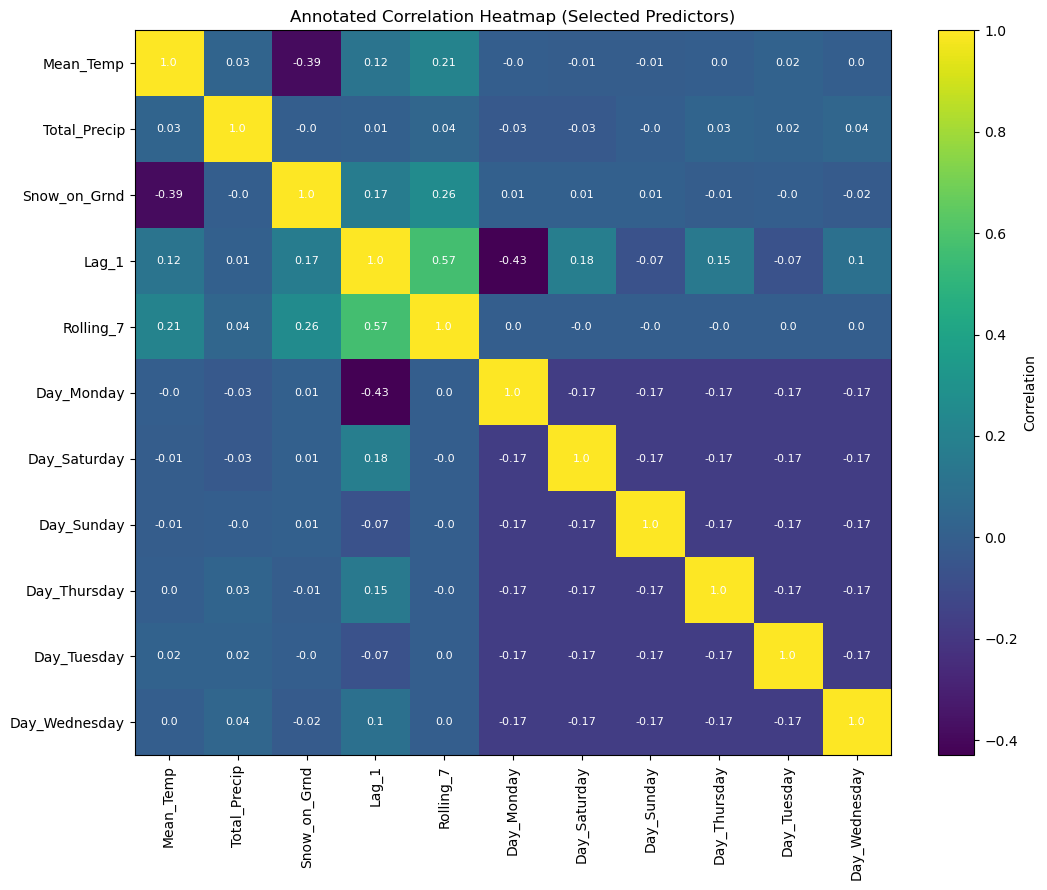

Top correlation pairs:
      Variable_1     Variable_2  Correlation
0          Lag_1      Rolling_7         0.57
1          Lag_1     Day_Monday        -0.43
2      Mean_Temp   Snow_on_Grnd        -0.39
3   Snow_on_Grnd      Rolling_7         0.26
4      Mean_Temp      Rolling_7         0.21
5          Lag_1   Day_Saturday         0.18
6   Snow_on_Grnd          Lag_1         0.17
7     Day_Monday   Day_Saturday        -0.17
8     Day_Monday     Day_Sunday        -0.17
9     Day_Monday   Day_Thursday        -0.17
10    Day_Monday    Day_Tuesday        -0.17
11  Day_Saturday     Day_Sunday        -0.17
12    Day_Monday  Day_Wednesday        -0.17
13  Day_Saturday   Day_Thursday        -0.17
14  Day_Saturday    Day_Tuesday        -0.17


In [156]:
# Select predictors
selected_cols = [
    'Mean_Temp',
    'Total_Precip',
    'Snow_on_Grnd',
    'Lag_1',
    'Rolling_7'
]

day_cols = [col for col in X.columns if col.startswith('Day_')]
selected_cols = selected_cols + day_cols

selected_df = X[selected_cols].copy()

# Correlation matrix
corr_selected = selected_df.corr().round(2)

#  Annotated heatmap 
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_selected, aspect='auto')
cbar = fig.colorbar(im)
cbar.set_label('Correlation')

ax.set_xticks(range(len(corr_selected.columns)))
ax.set_yticks(range(len(corr_selected.columns)))
ax.set_xticklabels(corr_selected.columns, rotation=90)
ax.set_yticklabels(corr_selected.columns)

# Write correlation values inside cells
for i in range(len(corr_selected.index)):
    for j in range(len(corr_selected.columns)):
        ax.text(j, i, corr_selected.iloc[i, j],
                ha='center', va='center', fontsize=8, color='white')

plt.title("Annotated Correlation Heatmap (Selected Predictors)")
plt.tight_layout()
plt.show()

#  Ranked correlation pairs 
corr_pairs = corr_selected.where(
    np.triu(np.ones(corr_selected.shape), k=1).astype(bool)
).stack().reset_index()

corr_pairs.columns = ['Variable_1', 'Variable_2', 'Correlation']
corr_pairs['Abs_Correlation'] = corr_pairs['Correlation'].abs()

corr_pairs = corr_pairs.sort_values(
    by='Abs_Correlation',
    ascending=False
).reset_index(drop=True)

print("Top correlation pairs:")
print(corr_pairs[['Variable_1', 'Variable_2', 'Correlation']].head(15))

# Create target variables

In [41]:
# modelling

In [42]:
# Define X and Y
X = final_df.drop(columns=['Date', 'Total_Delays'])
y = final_df['Total_Delays']

print(X.head())
print(y.head())
print(X.shape, y.shape)

   Mean_Temp  Cool_Deg_Days  Total_Precip  Snow_on_Grnd  Day_Monday  \
0       -0.5            0.0           0.0           0.0           0   
1       -3.1            0.0           0.0           0.0           0   
2        0.3            0.0           0.1           0.0           1   
3       -0.1            0.0           0.0           0.0           0   
4       -1.5            0.0           0.1           0.0           0   

   Day_Saturday  Day_Sunday  Day_Thursday  Day_Tuesday  Day_Wednesday  Lag_1  \
0             1           0             0            0              0  128.0   
1             0           1             0            0              0   90.0   
2             0           0             0            0              0   80.0   
3             0           0             0            1              0  131.0   
4             0           0             0            0              1  109.0   

    Rolling_7  Temp_Precip  Snow_Cold  Temp_sq  Precip_sq  
0  111.428571        -0.00      

# Split into training and testing sets

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (872, 16)
X_test: (218, 16)
y_train: (872,)
y_test: (218,)


# Hypertuning of parameters

In [53]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_cv = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

rf_cv.fit(X_train, y_train)

print("Best parameters:", rf_cv.best_params_)

best_rf = rf_cv.best_estimator_
y_pred_rf = best_rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print("Tuned Random Forest RMSE:", rf_rmse)
print("Tuned Random Forest MAE:", rf_mae)
print("Tuned Random Forest R²:", rf_r2)

Best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Tuned Random Forest RMSE: 30.56869771515713
Tuned Random Forest MAE: 22.7027608894029
Tuned Random Forest R²: 0.35371104808430287


In [54]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

ridge_cv = GridSearchCV(
    ridge,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)

ridge_cv.fit(X_train, y_train)

print("Best alpha:", ridge_cv.best_params_)

Best alpha: {'alpha': 0.01}


In [55]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

ridge_cv = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)

ridge_cv.fit(X_train, y_train)

print("Best alpha:", ridge_cv.best_params_)
print("Best model:", ridge_cv.best_estimator_)

Best alpha: {'alpha': 0.01}
Best model: Ridge(alpha=0.01)


In [56]:
# Fit the baseline linear regression model

from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Predict and evaluate

In [57]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = lr_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression RMSE:", rmse)
print("Linear Regression MAE:", mae)
print("Linear Regression R²:", r2)

Linear Regression RMSE: 27.826880257452974
Linear Regression MAE: 21.241563283935722
Linear Regression R²: 0.46444769161969457


The baseline linear regression model shows modest performance. The RMSE of 36.29 and MAE of 27.89 indicate substantial average prediction error, while the R² of 0.29 shows that the model explains only a limited share of daily delay variation. This suggests that the selected weather and temporal variables capture some meaningful patterns, but additional predictors would be needed for stronger forecasting accuracy.

In [ ]:
# Ridge Regression

In [58]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Fit Ridge model
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

# Predict
y_pred_ridge = ridge_model.predict(X_test)

# Evaluate
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_r2 = r2_score(y_test, y_pred_ridge)

print("Ridge Regression RMSE:", ridge_rmse)
print("Ridge Regression MAE:", ridge_mae)
print("Ridge Regression R²:", ridge_r2)

Ridge Regression RMSE: 27.816500504024447
Ridge Regression MAE: 21.199067569941082
Ridge Regression R²: 0.46484715171654734


The Ridge regression model produced nearly identical performance metrics to the baseline linear regression model, with no meaningful improvement in RMSE, MAE, or R². This indicates that multicollinearity among predictors is minimal and that coefficient shrinkage does not provide additional benefit for this dataset.

In [ ]:
# Lasso Regression

In [59]:
from sklearn.linear_model import Lasso

# Fit Lasso model
lasso_model = Lasso(alpha=0.01, max_iter=10000)
lasso_model.fit(X_train, y_train)

# Predict
y_pred_lasso = lasso_model.predict(X_test)

# Evaluate
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)
lasso_r2 = r2_score(y_test, y_pred_lasso)

print("Lasso Regression RMSE:", lasso_rmse)
print("Lasso Regression MAE:", lasso_mae)
print("Lasso Regression R²:", lasso_r2)

Lasso Regression RMSE: 27.824119237597756
Lasso Regression MAE: 21.225203683514874
Lasso Regression R²: 0.46455396276367067


In [ ]:
# RandomForest regression

In [61]:
# Fit randomForest

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest MAE:", rf_mae)
print("Random Forest R²:", rf_r2)

Random Forest RMSE: 30.910977956979632
Random Forest MAE: 23.194266055045873
Random Forest R²: 0.3391569179065802


In [ ]:
# Model comparison

In [62]:
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'RandomForest regression'],
    'RMSE': [rmse, ridge_rmse, lasso_rmse, rf_rmse],
    'MAE': [mae, ridge_mae, lasso_mae, rf_mae],
    'R2': [r2, ridge_r2, lasso_r2, rf_r2]
})

print(comparison_df)

                     Model       RMSE        MAE        R2
0        Linear Regression  27.826880  21.241563  0.464448
1         Ridge Regression  27.816501  21.199068  0.464847
2         Lasso Regression  27.824119  21.225204  0.464554
3  RandomForest regression  30.910978  23.194266  0.339157


In [ ]:
# Model tunning

In [63]:
# Evaluate best model
best_ridge = ridge_cv.best_estimator_

y_pred_ridge = best_ridge.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2 = r2_score(y_test, y_pred_ridge)

print("Tuned Ridge RMSE:", rmse)
print("Tuned Ridge R²:", r2)

Tuned Ridge RMSE: 27.826740092748693
Tuned Ridge R²: 0.4644530867873299


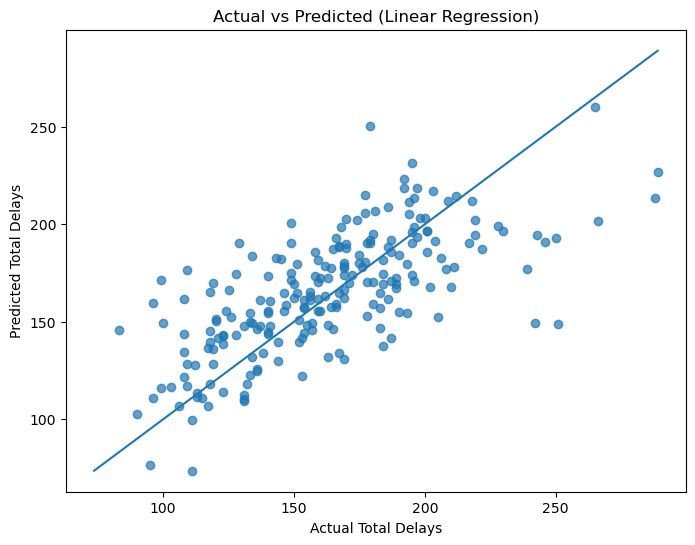

In [64]:
# Predict with best model

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)

plt.xlabel("Actual Total Delays")
plt.ylabel("Predicted Total Delays")
plt.title("Actual vs Predicted (Linear Regression)")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

In [85]:
X = final_df.drop(columns=['Date', 'Total_Delays'])
y = final_df['Total_Delays']

In [86]:
# feature importance for random forest

# Feature importance
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df)

          Feature  Importance
11      Rolling_7    0.423497
6      Day_Sunday    0.237821
10          Lag_1    0.105136
14        Temp_sq    0.044904
0       Mean_Temp    0.033882
3    Snow_on_Grnd    0.027824
12    Temp_Precip    0.026774
2    Total_Precip    0.022302
5    Day_Saturday    0.021636
15      Precip_sq    0.021251
1   Cool_Deg_Days    0.012031
4      Day_Monday    0.008276
8     Day_Tuesday    0.007980
7    Day_Thursday    0.003687
9   Day_Wednesday    0.002998
13      Snow_Cold    0.000000


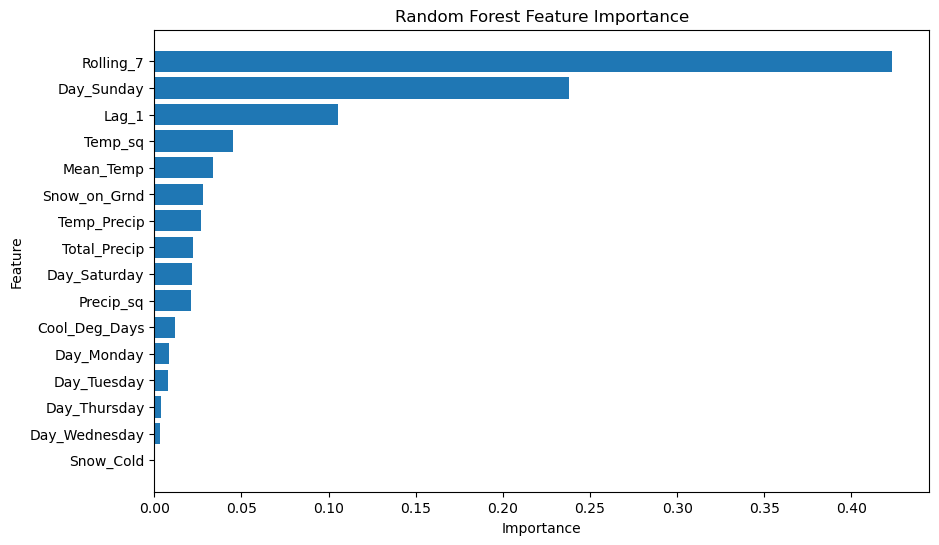

In [87]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [88]:
# Final comparison of all the four models

comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'Tuned Random Forest'],
    'RMSE': [rmse, ridge_rmse, lasso_rmse, rf_rmse],
    'MAE': [mae, ridge_mae, lasso_mae, rf_mae],
    'R2': [r2, ridge_r2, lasso_r2, rf_r2]
}).sort_values(by='RMSE')

print(comparison_df)

                 Model       RMSE        MAE        R2
1     Ridge Regression  27.816501  21.199068  0.464847
2     Lasso Regression  27.824119  21.225204  0.464554
0    Linear Regression  27.826740  21.241563  0.464453
3  Tuned Random Forest  30.910978  23.194266  0.339157


# CLASSIFICATION ANALYSIS

In [89]:
# Create ranked delay categories from Min Delay
def classify_delay(x):
    if x <= 8:
        return 'Low'
    elif x < 20:
        return 'Moderate'
    else:
        return 'High'

bus_df['Delay_Level'] = bus_df['Min Delay'].apply(classify_delay)

# Encode target as ordered classes
bus_df['Delay_Level'] = bus_df['Delay_Level'].map({
    'Low': 0,
    'Moderate': 1,
    'High': 2
})

print(bus_df[['Min Delay', 'Delay_Level']].head())
print(bus_df['Delay_Level'].value_counts())

   Min Delay  Delay_Level
0         81            2
1         22            2
2         30            2
3         17            1
4          1            0
Delay_Level
1    83940
2    51668
0    48881
Name: count, dtype: int64


In [90]:
# One-hot encode the categorical predictors 

classification_df = pd.get_dummies(
    bus_df,
    columns=['Day', 'Direction', 'Time_Period', 'Route'],
    drop_first=True
)

print(classification_df.head())
print(classification_df.shape)

        Date   Time  Min Delay  Min Gap Station  Year  Month  Is_Weekend  \
0 2023-01-01  02:30         81      111     NaN  2023      1           1   
1 2023-01-01  02:34         22       44     NaN  2023      1           1   
2 2023-01-01  03:06         30       60     NaN  2023      1           1   
3 2023-01-01  03:14         17       17     NaN  2023      1           1   
4 2023-01-01  03:43          1        1     NaN  2023      1           1   

   Delay_Level  Day_Monday  ...  Route_939  Route_939 FINCH EXPRESS  Route_95  \
0            2       False  ...      False                    False     False   
1            2       False  ...      False                    False     False   
2            2       False  ...      False                    False     False   
3            1       False  ...      False                    False     False   
4            0       False  ...      False                    False     False   

   Route_95 YORK MILLS  Route_96  Route_96 WILSON  Route

In [91]:
classification_df.to_csv("classification_dataset.csv", index=False)

In [92]:
# Drop the leakage columns

classification_df = classification_df.drop(
    columns=[
         'Min Delay', 'Min Gap', 'Delay_Level_Label'
    ], errors='ignore'
)

print(classification_df.columns.tolist())

['Date', 'Time', 'Station', 'Year', 'Month', 'Is_Weekend', 'Delay_Level', 'Day_Monday', 'Day_Saturday', 'Day_Sunday', 'Day_Thursday', 'Day_Tuesday', 'Day_Wednesday', 'Direction_N', 'Direction_S', 'Direction_Unknown', 'Direction_W', 'Time_Period_Midday', 'Time_Period_Morning_Rush', 'Time_Period_Night', 'Route_102 MARKHAM ROAD', 'Route_116', 'Route_116 MORNINGSIDE', 'Route_165', 'Route_165 WESTON ROAD NORTH', 'Route_24', 'Route_25', 'Route_25 DON MILLS', 'Route_29', 'Route_29 DUFFERIN', 'Route_300', 'Route_32', 'Route_32 EGLINTON WEST', 'Route_320', 'Route_34', 'Route_34 EGLINTON EAST', 'Route_35', 'Route_35 JANE', 'Route_36', 'Route_36 FINCH WEST', 'Route_37', 'Route_39', 'Route_41', 'Route_43', 'Route_45', 'Route_47', 'Route_52', 'Route_52 LAWRENCE WEST', 'Route_53', 'Route_53 STEELES EAST', 'Route_54', 'Route_54 LAWRENCE EAST', 'Route_60', 'Route_63', 'Route_63 OSSINGTON', 'Route_68', 'Route_7', 'Route_7 BATHURST', 'Route_72', 'Route_75', 'Route_84', 'Route_85', 'Route_85 SHEPPARD EAS

In [122]:
X = classification_df.drop(columns=['Delay_Level', 'Date', 'Time', 'Station'], errors='ignore')
y = classification_df['Delay_Level']

print(X.dtypes)

Year               int32
Month              int32
Is_Weekend         int64
Day_Monday          bool
Day_Saturday        bool
                   ...  
Route_96 WILSON     bool
Route_960           bool
Route_985           bool
Route_Other         bool
Route_Unknown       bool
Length: 75, dtype: object


In [128]:
# define X and Y
X = classification_df.drop(columns=['Delay_Level'])
y = classification_df['Delay_Level']

print(X.head())
print(y.head())
print(X_cls.shape, y.shape)
print(X.select_dtypes(include='object').columns.tolist())

        Date   Time Station  Year  Month  Is_Weekend  Day_Monday  \
0 2023-01-01  02:30     NaN  2023      1           1       False   
1 2023-01-01  02:34     NaN  2023      1           1       False   
2 2023-01-01  03:06     NaN  2023      1           1       False   
3 2023-01-01  03:14     NaN  2023      1           1       False   
4 2023-01-01  03:43     NaN  2023      1           1       False   

   Day_Saturday  Day_Sunday  Day_Thursday  ...  Route_939  \
0         False        True         False  ...      False   
1         False        True         False  ...      False   
2         False        True         False  ...      False   
3         False        True         False  ...      False   
4         False        True         False  ...      False   

   Route_939 FINCH EXPRESS  Route_95  Route_95 YORK MILLS  Route_96  \
0                    False     False                False     False   
1                    False     False                False     False   
2          

In [ ]:
# Test and train split

In [110]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X.columns)
print(X.dtypes)

Index(['Year', 'Month', 'Is_Weekend', 'Day_Monday', 'Day_Saturday',
       'Day_Sunday', 'Day_Thursday', 'Day_Tuesday', 'Day_Wednesday',
       'Direction_N', 'Direction_S', 'Direction_Unknown', 'Direction_W',
       'Time_Period_Midday', 'Time_Period_Morning_Rush', 'Time_Period_Night',
       'Route_102 MARKHAM ROAD', 'Route_116', 'Route_116 MORNINGSIDE',
       'Route_165', 'Route_165 WESTON ROAD NORTH', 'Route_24', 'Route_25',
       'Route_25 DON MILLS', 'Route_29', 'Route_29 DUFFERIN', 'Route_300',
       'Route_32', 'Route_32 EGLINTON WEST', 'Route_320', 'Route_34',
       'Route_34 EGLINTON EAST', 'Route_35', 'Route_35 JANE', 'Route_36',
       'Route_36 FINCH WEST', 'Route_37', 'Route_39', 'Route_41', 'Route_43',
       'Route_45', 'Route_47', 'Route_52', 'Route_52 LAWRENCE WEST',
       'Route_53', 'Route_53 STEELES EAST', 'Route_54',
       'Route_54 LAWRENCE EAST', 'Route_60', 'Route_63', 'Route_63 OSSINGTON',
       'Route_68', 'Route_7', 'Route_7 BATHURST', 'Route_72', 'Ro

In [127]:
print(type(X_train))
print(X_train.index.dtype)
print(X_test.index.dtype)

<class 'pandas.core.frame.DataFrame'>
int64
int64


# Fit Logistic Regression, Decision Tree, and Random Forest

OBJECTIVE: classify individual bus delay incidents into distinct severity categories—Low, Moderate, and High—based on operational, temporal, and contextual features.

In [129]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000, random_state=42,
    class_weight='balanced'
)

log_model.fit(X_train_scaled, y_train_cls)
y_pred_log = log_model.predict(X_test_scaled)



log_model = LogisticRegression(max_iter=5000, random_state=42)
log_model.fit(X_train_scaled, y_train_cls)

y_pred_log = log_model.predict(X_test_scaled)

Logistic Regression Accuracy: 0.490948018862811
Logistic Regression Precision: 0.5375524347862458
Logistic Regression Recall: 0.490948018862811
Logistic Regression F1: 0.4857622558436811
              precision    recall  f1-score   support

           0       0.51      0.46      0.48      9886
           1       0.63      0.37      0.47     16760
           2       0.40      0.72      0.52     10252

    accuracy                           0.49     36898
   macro avg       0.52      0.52      0.49     36898
weighted avg       0.54      0.49      0.49     36898



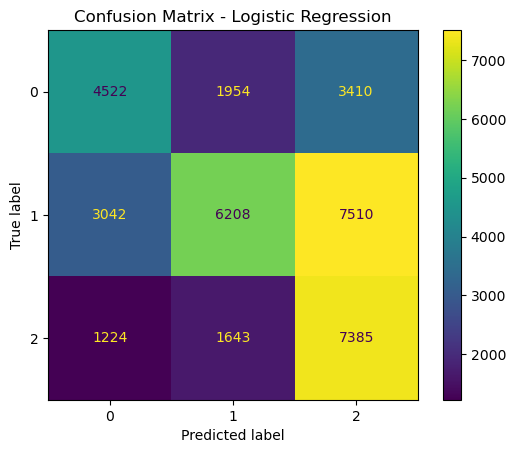

In [130]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

log_model = LogisticRegression(max_iter=5000, random_state=42, class_weight='balanced'
)
log_model.fit(X_train_scaled, y_train_cls)

y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test_cls, y_pred_log))
print("Logistic Regression Precision:", precision_score(y_test_cls, y_pred_log, average='weighted'))
print("Logistic Regression Recall:", recall_score(y_test_cls, y_pred_log, average='weighted'))
print("Logistic Regression F1:", f1_score(y_test_cls, y_pred_log, average='weighted'))
print(classification_report(y_test_cls, y_pred_log))

# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test_cls, y_pred_log)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Decision Tree Accuracy: 0.5213561710661825
Decision Tree Precision (weighted): 0.5470730318899322
Decision Tree Recall (weighted): 0.5213561710661825
Decision Tree F1 Score (weighted): 0.4835337509716183
              precision    recall  f1-score   support

           0       0.67      0.20      0.31      9886
           1       0.52      0.81      0.63     16760
           2       0.48      0.35      0.41     10252

    accuracy                           0.52     36898
   macro avg       0.56      0.46      0.45     36898
weighted avg       0.55      0.52      0.48     36898



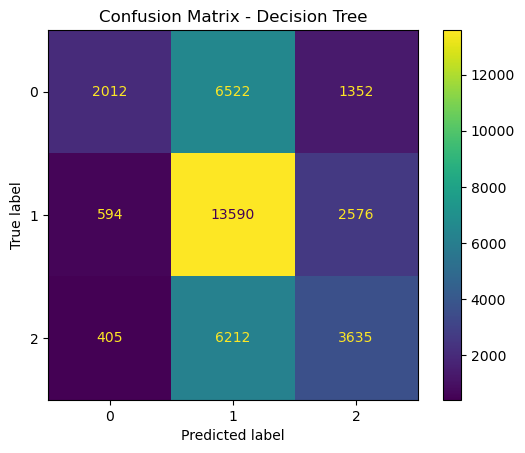

In [145]:
from sklearn.tree import DecisionTreeClassifier

# prevent overfitting of Decision 
dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree Precision (weighted):", precision_score(y_test, y_pred_dt, average='weighted'))
print("Decision Tree Recall (weighted):", recall_score(y_test, y_pred_dt, average='weighted'))
print("Decision Tree F1 Score (weighted):", f1_score(y_test, y_pred_dt, average='weighted'))
print(classification_report(y_test_cls, y_pred_dt))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt)
plt.title("Confusion Matrix - Decision Tree")
plt.show()

Random Forest Accuracy: 0.5214645780259093
Random Forest Precision: 0.5192150895701644
Random Forest Recall: 0.5214645780259093
Random Forest F1: 0.5155608931756468
              precision    recall  f1-score   support

           0       0.55      0.41      0.47      9886
           1       0.55      0.66      0.60     16760
           2       0.43      0.41      0.42     10252

    accuracy                           0.52     36898
   macro avg       0.51      0.49      0.50     36898
weighted avg       0.52      0.52      0.52     36898



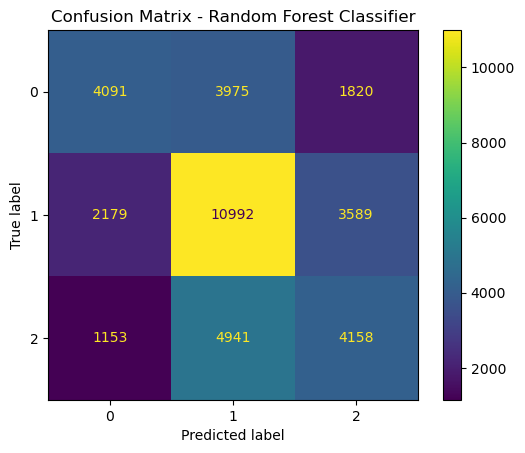

In [144]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Precision:", precision_score(y_test, y_pred_rf, average='weighted'))
print("Random Forest Recall:", recall_score(y_test, y_pred_rf, average='weighted'))
print("Random Forest F1:", f1_score(y_test, y_pred_rf, average='weighted'))
print(classification_report(y_test, y_pred_rf))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Confusion Matrix - Random Forest Classifier")
plt.show()

In [ ]:
# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test_cls, y_pred_log)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Random Forest Accuracy: 0.5027101739931703
Random Forest Precision: 0.5162415351319992
Random Forest Recall: 0.5027101739931703
Random Forest F1: 0.5055613529684113
              precision    recall  f1-score   support

           0       0.49      0.47      0.48      9776
           1       0.60      0.50      0.55     16788
           2       0.41      0.53      0.47     10334

    accuracy                           0.50     36898
   macro avg       0.50      0.50      0.50     36898
weighted avg       0.52      0.50      0.51     36898



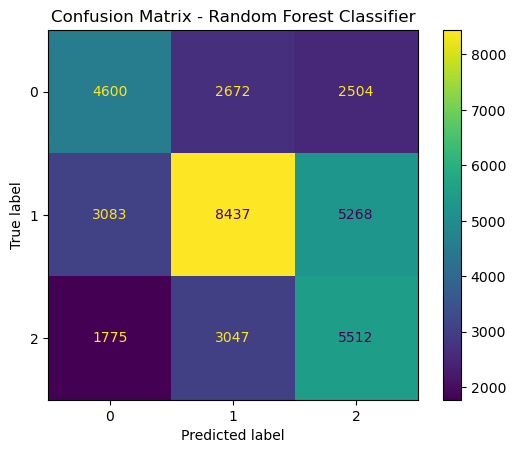

In [122]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_clf.fit(X_train_cls, y_train_cls)


rf_clf.fit(X_train_cls, y_train_cls)
y_pred_rf = rf_clf.predict(X_test_cls)

print("Random Forest Accuracy:", accuracy_score(y_test_cls, y_pred_rf))
print("Random Forest Precision:", precision_score(y_test_cls, y_pred_rf, average='weighted'))
print("Random Forest Recall:", recall_score(y_test_cls, y_pred_rf, average='weighted'))
print("Random Forest F1:", f1_score(y_test_cls, y_pred_rf, average='weighted'))
print(classification_report(y_test_cls, y_pred_rf))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test_cls,
    y_pred_rf
)
plt.title("Confusion Matrix - Random Forest Classifier")
plt.show()

In [146]:
# Compare the three models 
comparison_cls = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test_cls, y_pred_log),
        accuracy_score(y_test_cls, y_pred_dt),
        accuracy_score(y_test_cls, y_pred_rf)
    ],
    'Precision_Weighted': [
        precision_score(y_test_cls, y_pred_log, average='weighted'),
        precision_score(y_test_cls, y_pred_dt, average='weighted'),
        precision_score(y_test_cls, y_pred_rf, average='weighted')
    ],
    'Recall_Weighted': [
        recall_score(y_test_cls, y_pred_log, average='weighted'),
        recall_score(y_test_cls, y_pred_dt, average='weighted'),
        recall_score(y_test_cls, y_pred_rf, average='weighted')
    ],
    'F1_Weighted': [
        f1_score(y_test_cls, y_pred_log, average='weighted'),
        f1_score(y_test_cls, y_pred_dt, average='weighted'),
        f1_score(y_test_cls, y_pred_rf, average='weighted')
    ]
}).sort_values(by='F1_Weighted', ascending=False)

print(comparison_cls)

                 Model  Accuracy  Precision_Weighted  Recall_Weighted  \
2        Random Forest  0.521465            0.519215         0.521465   
0  Logistic Regression  0.490948            0.537552         0.490948   
1        Decision Tree  0.521356            0.547073         0.521356   

   F1_Weighted  
2     0.515561  
0     0.485762  
1     0.483534  


In [ ]:
# confusion matrix for the best model

In [147]:
best_model_name = comparison_cls.iloc[0]['Model']
print("Best model:", best_model_name)

Best model: Random Forest


In [ ]:
# confusion matrix for the best model

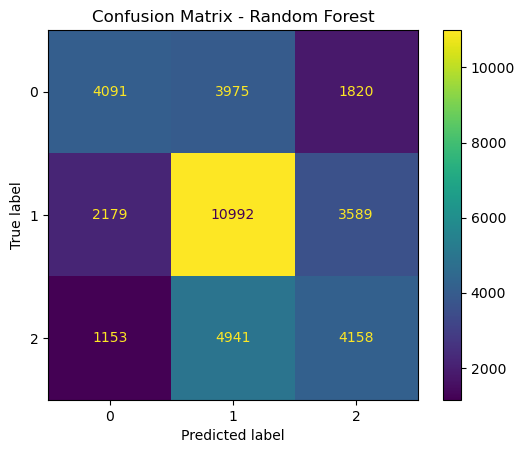

In [149]:
from sklearn.metrics import ConfusionMatrixDisplay

# Select correct predictions
if best_model_name == 'Logistic Regression':
    y_pred_best = y_pred_log
elif best_model_name == 'Decision Tree':
    y_pred_best = y_pred_dt
elif best_model_name == 'Random Forest':
    y_pred_best = y_pred_rf

# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

# OBJECTIVE: Identify routes with different delay levels

In [150]:
# create delay levels

def classify_delay(x):
    if x <= 8:
        return 'Low'
    elif x < 20:
        return 'Moderate'
    else:
        return 'High'

bus_df['Delay_Level_Label'] = bus_df['Min Delay'].apply(classify_delay)

print(bus_df[['Route', 'Min Delay', 'Delay_Level_Label']].head())

   Route  Min Delay Delay_Level_Label
0  Other         81              High
1  Other         22              High
2     35         30              High
3  Other         17          Moderate
4     85          1               Low


In [151]:
# Count delay levels by route

route_delay_counts = pd.crosstab(
    bus_df['Route'],
    bus_df['Delay_Level_Label']
)

print(route_delay_counts.head(20))

Delay_Level_Label      High   Low  Moderate
Route                                      
102                     722   399       813
102 MARKHAM ROAD        538   290       479
116                      84   784       790
116 MORNINGSIDE          36   709       267
165                     103   580       807
165 WESTON ROAD NORTH    71   631       359
24                      194   278       762
25                      103   639       581
25 DON MILLS             38   497       466
29                      205  1722       746
29 DUFFERIN             196   660       505
300                     163   410       339
32                      497   488      2706
32 EGLINTON WEST        229   486      1154
320                      82   784       123
34                      232   431       801
34 EGLINTON EAST        142   221       546
35                      225  1179      1237
35 JANE                 140   253       578
36                      307  2362       562


In [152]:
# Add totals and rank routes

route_delay_counts['Total'] = route_delay_counts.sum(axis=1)

route_delay_counts = route_delay_counts.sort_values(
    by='Total',
    ascending=False
)

print(route_delay_counts.head(20))

Delay_Level_Label   High    Low  Moderate  Total
Route                                           
Other              35673  20000     40779  96452
32                   497    488      2706   3691
36                   307   2362       562   3231
52                  1369    302      1398   3069
29                   205   1722       746   2673
35                   225   1179      1237   2641
7                    163    419      1627   2209
63                   168    788      1185   2141
Unknown               87   1829       108   2024
102                  722    399       813   1934
54                   359    308      1259   1926
32 EGLINTON WEST     229    486      1154   1869
95                   176    222      1437   1835
85                   594    344       864   1802
41                   291    312      1194   1797
96                   976    187       546   1709
47                   551    199       959   1709
52 LAWRENCE WEST     907    198       582   1687
116                 

In [153]:
# Identify routes dominated by High delays

route_delay_counts['High_Proportion'] = (
    route_delay_counts['High'] / route_delay_counts['Total']
)

high_delay_routes = route_delay_counts.sort_values(
    by='High_Proportion',
    ascending=False
)

print(high_delay_routes.head(20))

Delay_Level_Label   High    Low  Moderate  Total  High_Proportion
Route                                                            
96                   976    187       546   1709         0.571094
68                   487    110       263    860         0.566279
37                   582     81       371   1034         0.562863
52 LAWRENCE WEST     907    198       582   1687         0.537641
52                  1369    302      1398   3069         0.446074
96 WILSON            439    169       427   1035         0.424155
102 MARKHAM ROAD     538    290       479   1307         0.411630
102                  722    399       813   1934         0.373320
Other              35673  20000     40779  96452         0.369852
85                   594    344       864   1802         0.329634
47                   551    199       959   1709         0.322411
53                   414    660       451   1525         0.271475
72                   325    620       361   1306         0.248851
53 STEELES

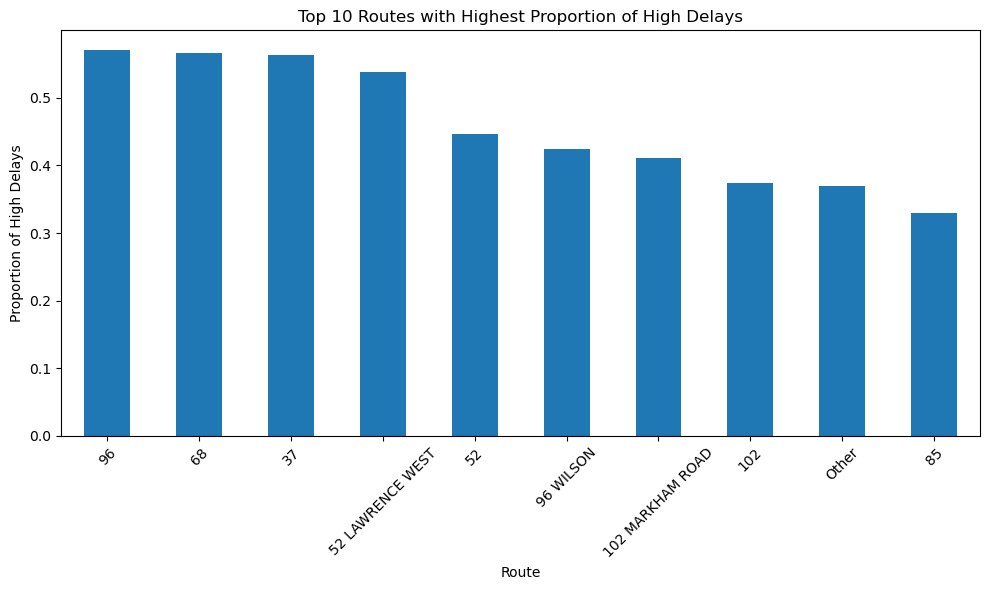

In [156]:
# Visualize top routes by highest proportion of delays

high_delay_routes_filtered = high_delay_routes.sort_values(
    by='High_Proportion', ascending=False
)
top_high_prop = high_delay_routes_filtered.head(10)

top_high_prop['High_Proportion'].plot(kind='bar', figsize=(10, 6))
plt.title("Top 10 Routes with Highest Proportion of High Delays")
plt.xlabel("Route")
plt.ylabel("Proportion of High Delays")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# OBJECTIVE: identify routes with different delay levels per day

In [157]:
# Count delay levels for each route on each day

route_day_delay = pd.crosstab(
    [bus_df['Day'], bus_df['Route']],
    bus_df['Delay_Level_Label']
).reset_index()

print(route_day_delay.head(20))

Delay_Level_Label     Day                  Route  High  Low  Moderate
0                  Friday                    102   148   52       115
1                  Friday       102 MARKHAM ROAD    99   33        81
2                  Friday                    116    18  122       120
3                  Friday        116 MORNINGSIDE     9  101        36
4                  Friday                    165     9  103       107
5                  Friday  165 WESTON ROAD NORTH     6  100        51
6                  Friday                     24    37   35       140
7                  Friday                     25    16  136        72
8                  Friday           25 DON MILLS     4  102        49
9                  Friday                     29    31  269       113
10                 Friday            29 DUFFERIN    42   87        62
11                 Friday                    300    14   62        56
12                 Friday                     32    79  105       472
13                 F

In [158]:
# total delays and high-delay proportion

route_day_delay['Total'] = route_day_delay[['Low', 'Moderate', 'High']].sum(axis=1)
route_day_delay['High_Proportion'] = route_day_delay['High'] / route_day_delay['Total']

print(route_day_delay.head(20))

Delay_Level_Label     Day                  Route  High  Low  Moderate  Total  \
0                  Friday                    102   148   52       115    315   
1                  Friday       102 MARKHAM ROAD    99   33        81    213   
2                  Friday                    116    18  122       120    260   
3                  Friday        116 MORNINGSIDE     9  101        36    146   
4                  Friday                    165     9  103       107    219   
5                  Friday  165 WESTON ROAD NORTH     6  100        51    157   
6                  Friday                     24    37   35       140    212   
7                  Friday                     25    16  136        72    224   
8                  Friday           25 DON MILLS     4  102        49    155   
9                  Friday                     29    31  269       113    413   
10                 Friday            29 DUFFERIN    42   87        62    191   
11                 Friday               

In [139]:
# routes with the most High delays per day

top_high_by_day = route_day_delay.sort_values(
    by=['Day', 'High'],
    ascending=[True, False]
)

print(top_high_by_day.head(30))

Delay_Level_Label     Day             Route  High   Low  Moderate  Total  \
58                 Friday             Other  5530  3163      6863  15556   
27                 Friday                52   234    49       292    575   
0                  Friday               102   148    52       115    315   
54                 Friday                96   142    26        84    252   
28                 Friday  52 LAWRENCE WEST   130    30        94    254   
26                 Friday                47   102    31       142    275   
1                  Friday  102 MARKHAM ROAD    99    33        81    213   
55                 Friday         96 WILSON    94    27        44    165   
36                 Friday                68    84    17        45    146   
42                 Friday                85    80    38       139    257   
12                 Friday                32    79   105       472    656   
21                 Friday                37    73    13        54    140   
39          

In [159]:
# TOP 5 ROUTES DELAY PER DAY

top5_per_day = (
    route_day_delay[route_day_delay['Total'] >= 20]
    .sort_values(['Day', 'High_Proportion'], ascending=[True, False])
    .groupby('Day')
    .head(5)
)

print(top5_per_day)

Delay_Level_Label        Day             Route  High  Low  Moderate  Total  \
36                    Friday                68    84   17        45    146   
55                    Friday         96 WILSON    94   27        44    165   
54                    Friday                96   142   26        84    252   
21                    Friday                37    73   13        54    140   
28                    Friday  52 LAWRENCE WEST   130   30        94    254   
114                   Monday                96   143   19        65    227   
81                    Monday                37    89   15        47    151   
96                    Monday                68    69   24        34    127   
88                    Monday  52 LAWRENCE WEST   116   23       102    241   
61                    Monday  102 MARKHAM ROAD    81   27        74    182   
148                 Saturday  52 LAWRENCE WEST   150   26        27    203   
147                 Saturday                52   269   43       

# Objectives: identify routes with different delay levels by hour per day

In [160]:
import pandas as pd

bus_df['Time'] = bus_df['Time'].astype(str).str.strip()
bus_df['Hour'] = pd.to_datetime(bus_df['Time'], format='%H:%M', errors='coerce').dt.hour
print(bus_df[['Time', 'Hour']].head())

    Time  Hour
0  02:30     2
1  02:34     2
2  03:06     3
3  03:14     3
4  03:43     3


In [161]:
# count routes by day, hour, and delay level

route_hour_day_delay = (
    bus_df
    .groupby(['Day', 'Hour', 'Route', 'Delay_Level_Label'])
    .size()
    .reset_index(name='Count')
)
print(route_hour_day_delay.head())

      Day  Hour             Route Delay_Level_Label  Count
0  Friday     0               102              High      3
1  Friday     0               102               Low      1
2  Friday     0               102          Moderate      4
3  Friday     0  102 MARKHAM ROAD          Moderate      6
4  Friday     0               116          Moderate      4


In [162]:
# Sort in descending order
route_hour_day_delay = route_hour_day_delay.sort_values(
    by='Count',
    ascending=False
).reset_index(drop=True)

route_hour_day_delay['Rank'] = route_hour_day_delay.index + 1
print(route_hour_day_delay.head(20))

          Day  Hour  Route Delay_Level_Label  Count  Rank
0   Wednesday    17  Other          Moderate    642     1
1   Wednesday    16  Other          Moderate    627     2
2      Friday    17  Other          Moderate    617     3
3   Wednesday    15  Other          Moderate    597     4
4      Monday    15  Other          Moderate    589     5
5    Thursday    15  Other          Moderate    587     6
6      Friday    16  Other          Moderate    587     7
7    Thursday    16  Other          Moderate    585     8
8      Friday    15  Other          Moderate    575     9
9     Tuesday    16  Other          Moderate    568    10
10   Thursday    17  Other          Moderate    557    11
11    Tuesday    17  Other          Moderate    551    12
12     Monday    17  Other          Moderate    513    13
13    Tuesday    15  Other          Moderate    502    14
14  Wednesday    18  Other          Moderate    496    15
15    Tuesday     6  Other          Moderate    495    16
16    Tuesday 

In [163]:
# Top route-hour-day combinations for High delays

high_routes = route_hour_day_delay[
    route_hour_day_delay['Delay_Level_Label'] == 'High'
].sort_values(by='Count', ascending=False)

print(high_routes.head(20))

          Day  Hour  Route Delay_Level_Label  Count  Rank
40  Wednesday    17  Other              High    344    41
42     Friday    17  Other              High    339    43
44     Friday    14  Other              High    336    45
46  Wednesday    14  Other              High    335    47
47  Wednesday    18  Other              High    333    48
50   Thursday    14  Other              High    329    51
55    Tuesday    17  Other              High    317    56
56   Thursday    13  Other              High    316    57
57   Saturday    17  Other              High    315    58
58     Friday    13  Other              High    314    59
59     Friday    15  Other              High    313    60
61  Wednesday    16  Other              High    310    62
64   Saturday     6  Other              High    307    65
65  Wednesday    13  Other              High    305    66
68   Thursday    15  Other              High    302    69
70    Tuesday    14  Other              High    301    71
72    Tuesday 

In [164]:
# Top route-hour-day combinations for Moderate delays

moderate_routes = route_hour_day_delay[
    route_hour_day_delay['Delay_Level_Label'] == 'Moderate'
].sort_values(by='Count', ascending=False)

print(moderate_routes.head(20))

          Day  Hour  Route Delay_Level_Label  Count  Rank
0   Wednesday    17  Other          Moderate    642     1
1   Wednesday    16  Other          Moderate    627     2
2      Friday    17  Other          Moderate    617     3
3   Wednesday    15  Other          Moderate    597     4
4      Monday    15  Other          Moderate    589     5
6      Friday    16  Other          Moderate    587     7
5    Thursday    15  Other          Moderate    587     6
7    Thursday    16  Other          Moderate    585     8
8      Friday    15  Other          Moderate    575     9
9     Tuesday    16  Other          Moderate    568    10
10   Thursday    17  Other          Moderate    557    11
11    Tuesday    17  Other          Moderate    551    12
12     Monday    17  Other          Moderate    513    13
13    Tuesday    15  Other          Moderate    502    14
14  Wednesday    18  Other          Moderate    496    15
15    Tuesday     6  Other          Moderate    495    16
16    Tuesday 

In [165]:
# Top route-hour-day combinations for Low delays

low_routes = route_hour_day_delay[
    route_hour_day_delay['Delay_Level_Label'] == 'Low'
].sort_values(by='Count', ascending=False)

print(low_routes.head(20))

           Day  Hour  Route Delay_Level_Label  Count  Rank
62   Wednesday    16  Other               Low    308    63
79     Tuesday    16  Other               Low    293    80
87    Thursday    16  Other               Low    288    88
92   Wednesday    15  Other               Low    286    93
98    Thursday    15  Other               Low    283    99
109     Friday    16  Other               Low    278   110
127     Friday    15  Other               Low    263   128
157   Thursday    17  Other               Low    244   158
172  Wednesday    17  Other               Low    234   173
171   Thursday     8  Other               Low    234   172
180   Thursday    14  Other               Low    227   181
183    Tuesday    15  Other               Low    225   184
195   Saturday    16  Other               Low    216   196
201   Thursday     9  Other               Low    211   202
207  Wednesday     6  Other               Low    208   208
213     Friday    14  Other               Low    205   2

In [166]:
# the top 10 per delay level
top10_by_level = (
    route_hour_day_delay
    .sort_values(['Delay_Level_Label', 'Count'], ascending=[True, False])
    .groupby('Delay_Level_Label')
    .head(10)
)

print(top10_by_level)

           Day  Hour  Route Delay_Level_Label  Count  Rank
40   Wednesday    17  Other              High    344    41
42      Friday    17  Other              High    339    43
44      Friday    14  Other              High    336    45
46   Wednesday    14  Other              High    335    47
47   Wednesday    18  Other              High    333    48
50    Thursday    14  Other              High    329    51
55     Tuesday    17  Other              High    317    56
56    Thursday    13  Other              High    316    57
57    Saturday    17  Other              High    315    58
58      Friday    13  Other              High    314    59
62   Wednesday    16  Other               Low    308    63
79     Tuesday    16  Other               Low    293    80
87    Thursday    16  Other               Low    288    88
92   Wednesday    15  Other               Low    286    93
98    Thursday    15  Other               Low    283    99
109     Friday    16  Other               Low    278   1

In [152]:
route_hour_day_delay.to_csv("route_day_hour_delay_ranked.csv", index=False)